#### Loading packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#### Setting root directory path

In [2]:
ROOT = r'C:\Users\PC_DS_ECON_5\Desktop\data-analytics-python'


#### Data source used: NLSY97

The NLSY97 is a `longitudinal` (i.e. `panel`) survey of individuals born between 1980 and 1984. The first round of data collection took place in 1997 and was followed by additional survey rounds every one or two years.


#### Loading data

Reminder: We need the `pyarrow` package to import a `.parquet` datafile.

In [3]:
nlsy97_income_hours_all_df = pd.read_parquet(ROOT + '/data/nlsy97_income_hours_all_df.parquet')
nlsy97_additional_vars_df = pd.read_parquet(ROOT + '/data/nlsy97_additional_vars_df.parquet')


#### Dictionary of variable labels

In [4]:
long_varlabels_dict = {
    'gender': 'Gender',
    'ethnicity': 'Ethnicity',
    'educ': 'Highest Grade Completed',
    'degree': 'Highest Degree Earned',
    'meduc_bio': 'Highest Grade Completed (Biological Mother)',
    'meduc_res': 'Highest Grade Completed (Residential Mother)',
    'feduc_bio': 'Highest Grade Completed (Biological Father)',
    'feduc_res': 'Highest Grade Completed (Residential Father)',
    'educ_num': 'Inferred Years of Education',
    'educ_cat': 'Highest Degree Earned',
    'meduc_bio_num': 'Inferred Years of Education (Biological Mother)',
    'meduc_res_num': 'Inferred Years of Education (Residential Mother)',
    'feduc_bio_num': 'Inferred Years of Education (Biological Father)',
    'feduc_res_num': 'Inferred Years of Education (Residential Father)',
    'meduc_bio_cat': 'Inferred Degree (Biological Mother)',
    'meduc_res_cat': 'Inferred Degree (Residential Mother)',
    'feduc_bio_cat': 'Inferred Degree (Biological Father)',
    'feduc_res_cat': 'Inferred Degree (Residential Father)',
    'hh_yinc_1997': 'Household Income in 1997',
    'hh_yinc_source_1997': 'Source of Household Income in 1997', 
    'hh_net_worth_1997': 'Household Net Worth in 1997',
    'ASVAB_score': 'ASVAB score percentile (x1000)',
    'ASVAB_pct': 'ASVAB score percentile'
}


short_varlabels_dict = {
    'gender': 'Gender',
    'ethnicity': 'Ethnicity',
    'educ': 'Highest Grade Completed',
    'degree': 'Highest Degree Earned',
    'meduc_bio': 'Highest Grade Compl. (Biol. Mother)',
    'meduc_res': 'Highest Grade Compl. (Resid. Mother)',
    'feduc_bio': 'Highest Grade Compl. (Biol. Father)',
    'feduc_res': 'Highest Grade Compl. (Resid. Father)',
    'educ_num': 'Inferred Years of Educ.',
    'educ_cat': 'Highest Degree Earned',
    'meduc_bio_num': 'Inferred Years of Educ. (Biol. Mother)',
    'meduc_res_num': 'Inferred Years of Educ. (Resid. Mother)',
    'feduc_bio_num': 'Inferred Years of Educ. (Biol. Father)',
    'feduc_res_num': 'Inferred Years of Educ. (Resid. Father)',
    'meduc_bio_cat': 'Inferred Highest Degree (Biol. Mother)',
    'meduc_res_cat': 'Inferred Highest Degree (Resid. Mother)',
    'feduc_bio_cat': 'Inferred Highest Degree (Biol. Father)',
    'feduc_res_cat': 'Inferred Highest Degree (Resid. Father)',
    'hh_yinc_1997': 'HH Income in 1997',
    'hh_yinc_source_1997': 'Source of HH Income in 1997', 
    'hh_net_worth_1997': 'HH Net Worth in 1997',
    'ASVAB_score': 'ASVAB score ptile (x1000)',
    'ASVAB_pct': 'ASVAB score ptile'
}

#### Intergenerational Transmission of Educational Attainment (mother/father)

In the NLSY97 there are two commonly used measures of educational attainment:

 - highest grade completed (here the variable `educ`)
 - highest degree earned (here the variable `degree`)

The variable `educ` records the highest grade or year of education completed, while `degree` records the highest educational credential earned (e.g. high school diploma, bachelor's degree, master's degree).

For the parents of respondents, only a measure corresponding to highest grade completed is available. The relevant variables are:

 - highest grade completed by the biological mother (`meduc_bio`)
 - highest grade completed by the residential mother (`meduc_res`)
 - highest grade completed by the biological father (`feduc_bio`)
 - highest grade completed by the residential father (`feduc_res`)


Let us first look at the content of the `educ`-type variables. These are ordered categorical variables.

In [5]:
nlsy97_additional_vars_df['educ'].dtype

CategoricalDtype(categories=['1st grade', '2nd grade', '3rd grade', '4th grade',
                  '5th grade', '6th grade', '7th grade', '8th grade',
                  '9th grade', '10th grade', '11th grade', '12th grade',
                  '1st year college', '2nd year college', '3rd year college',
                  '4th year college', '5th year college', '6th year college',
                  '7th year college', '8th year college or more'],
, ordered=True, categories_dtype=str)

Let us plot the histogram of highest grade completed for participants, their mothers, their fathers for the representative sub-sample (`sample='Cross-sectional'`).

In [6]:
nlsy97_additional_vars_df['sample'].value_counts()

sample
Cross-sectional    6748
Oversample         2236
Name: count, dtype: int64[pyarrow]

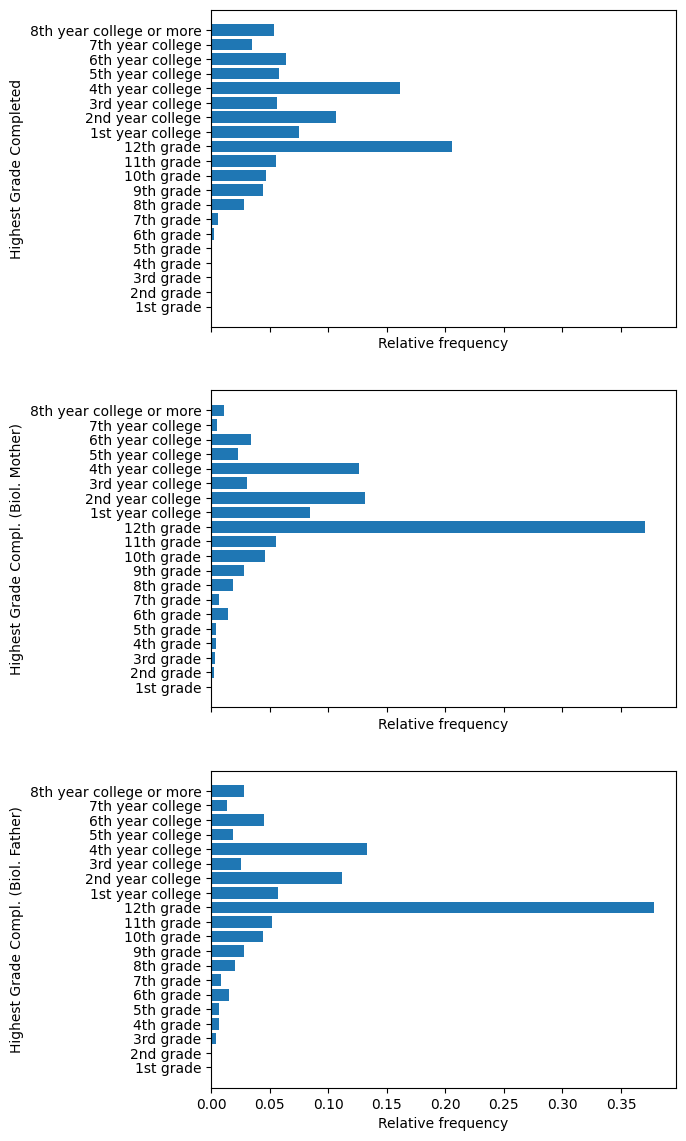

In [7]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(6,14), sharex=True, sharey=True)
varnames = ['educ', 'meduc_bio', 'feduc_bio']

for i, varname in enumerate(varnames):
    df = nlsy97_additional_vars_df.copy()
    df = (
        df
            .loc[df['sample'].eq('Cross-sectional'), varname]
            .value_counts(normalize=True)
            .reset_index()
            .sort_values(varname)
            .reset_index(drop=True)
    )
    axs[i].barh(y=df[varname].astype(str), width=df['proportion'], height=0.8)
    axs[i].set_xlabel('Relative frequency')
    axs[i].set_ylabel(short_varlabels_dict[varname])

There are corresponding variables (`educ_num`, `meduc_bio_num`, `meduc_res_num`, `feduc_bio_num`, `feduc_res_num`) that translate these ordered categorical variables into a numerical variable (years of education).



In [8]:
varname = 'educ'
df = nlsy97_additional_vars_df.copy()
df = (
    df[[varname, varname + '_num']]
        .loc[df['sample'].eq('Cross-sectional'),:]
        .value_counts(normalize=True)
        .reset_index()
        .sort_values([varname, varname + '_num'])
        .reset_index(drop=True)
        .copy()
)
df = df.loc[df['proportion'].ne(0),:].copy()
df

,educ,educ_num,proportion
17,2nd grade,2,0.000150
69,5th grade,5,0.000750
87,6th grade,6,0.002850
105,7th grade,7,0.005551
123,8th grade,8,0.028503
141,9th grade,9,0.044704
159,10th grade,10,0.046805
177,11th grade,11,0.055206
195,12th grade,12,0.205371
213,1st year college,13,0.074857


The `degree` variable exists only for the study participants, but not for their parents. It is an ordered categorical variable.

In [9]:
df = nlsy97_additional_vars_df.copy()
df['degree'].dtype


CategoricalDtype(categories=['No degree', 'GED', 'High school', 'Junior college',
                  'Bachelor', 'Master', 'Professional', 'PhD'],
, ordered=True, categories_dtype=str)

In [10]:
df0 = df.loc[
    df['educ'].notna() & df['degree'].isna(),
    ['educ', 'degree']
].value_counts(dropna=False).reset_index().copy()

df0 = df0.loc[df0['count'] > 0,:]

df0.sort_values('educ')

,educ,degree,count
0,12th grade,NaN,19
1,1st year college,NaN,6
2,2nd year college,NaN,2
3,3rd year college,NaN,2
7,4th year college,NaN,1
5,5th year college,NaN,1
6,6th year college,NaN,1
4,7th year college,NaN,1


Let us recode participants' and parents' highest grade completed into broader categories.

For participants, we use the following rule:

$$
educ\_cat = 
\begin{cases}
\text{Less than High School} & \text{if } degree = \text{No degree} \text{ or } degree = \text{GED}\\
\text{High School} & \text{if } degree = \text{High school} \text{ and } educ\_num \leq 12\\
\text{Some College} & \text{if } (degree = \text{High school} \text{ and } educ\_num > 12) \text{ or } degree = \text{Junior college}\\
\text{Bachelor Plus} & \text{if } degree \in \{\text{Bachelor}, \text{Master}, \text{Professional}, \text{PhD}\}
\end{cases}
$$

For parents, we use the following rule:

$$
[m/f]educ\_cat = 
\begin{cases}
\text{Less than High School} & \text{if } [m/f]educ\_num \leq 11\\
\text{High School} & \text{if } [m/f]educ\_num = 12\\
\text{Some College} & \text{if } [m/f]educ\_num \in [13,15] \\
\text{Bachelor Plus} & \text{if } [m/f]educ\_num \geq 16
\end{cases}
$$



In [11]:
df = nlsy97_additional_vars_df.copy()
varnames = ['meduc_bio', 'meduc_res', 'feduc_bio', 'feduc_res']
categories = ['Less than High School', 'High School', 'Some College', 'Bachelor Plus']
for varname in varnames:
    df[varname + '_cat'] = pd.NA 
    df.loc[df[varname + '_num'].lt(12), varname + '_cat'] = categories[0]
    df.loc[df[varname + '_num'].eq(12), varname + '_cat'] = categories[1]
    df.loc[df[varname + '_num'].gt(12) & df[varname + '_num'].lt(16), varname + '_cat'] = categories[2]
    df.loc[df[varname + '_num'].ge(16), varname + '_cat'] = categories[3]
    df[varname + '_cat'] = pd.Categorical(df[varname + '_cat'], categories=categories, ordered=True)


df['educ_cat'] = pd.NA
df.loc[df['degree'].eq('No degree'), 'educ_cat'] = categories[0]
df.loc[df['degree'].eq('GED'), 'educ_cat'] = categories[0]
df.loc[df['degree'].eq('High school') & df['educ_num'].le(12), 'educ_cat'] = categories[1]
df.loc[df['degree'].eq('High school') & df['educ_num'].gt(12), 'educ_cat'] = categories[2]
df.loc[df['degree'].eq('Junior college'), 'educ_cat'] = categories[2]
df.loc[df['degree'].eq('Bachelor'), 'educ_cat'] = categories[3]
df.loc[df['degree'].eq('Master'), 'educ_cat'] = categories[3]
df.loc[df['degree'].eq('Professional'), 'educ_cat'] = categories[3]
df.loc[df['degree'].eq('PhD'), 'educ_cat'] = categories[3]
df['educ_cat'] = pd.Categorical(df['educ_cat'], categories=categories, ordered=True)

nlsy97_additional_vars_df = df.copy()        

In [12]:
nlsy97_additional_vars_df['educ_cat'].dtype

CategoricalDtype(categories=['Less than High School', 'High School', 'Some College',
                  'Bachelor Plus'],
, ordered=True, categories_dtype=str)

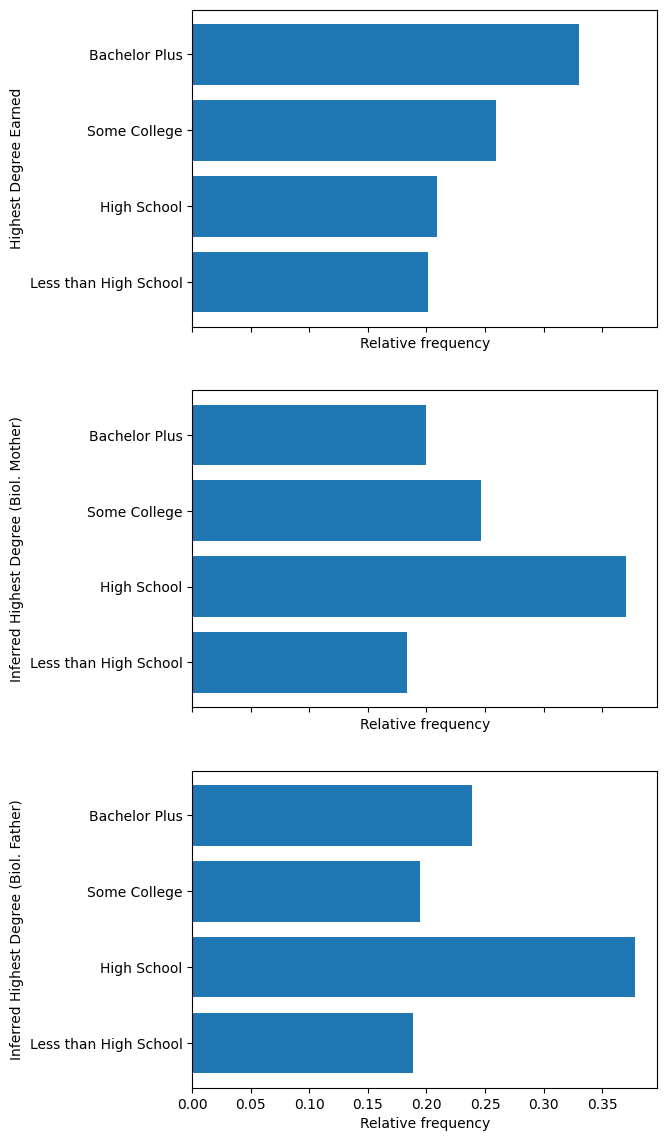

In [13]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(6,14), sharex=True, sharey=True)
varnames = ['educ_cat', 'meduc_bio_cat', 'feduc_bio_cat']

for i, varname in enumerate(varnames):
    df = nlsy97_additional_vars_df.copy()
    df = (
        df
            .loc[df['sample'].eq('Cross-sectional'), varname]
            .value_counts(normalize=True)
            .reset_index()
            .sort_values(varname)
            .reset_index(drop=True)
    )
    axs[i].barh(y=df[varname].astype(str), width=df['proportion'], height=0.8)
    axs[i].set_xlabel('Relative frequency')
    axs[i].set_ylabel(short_varlabels_dict[varname])

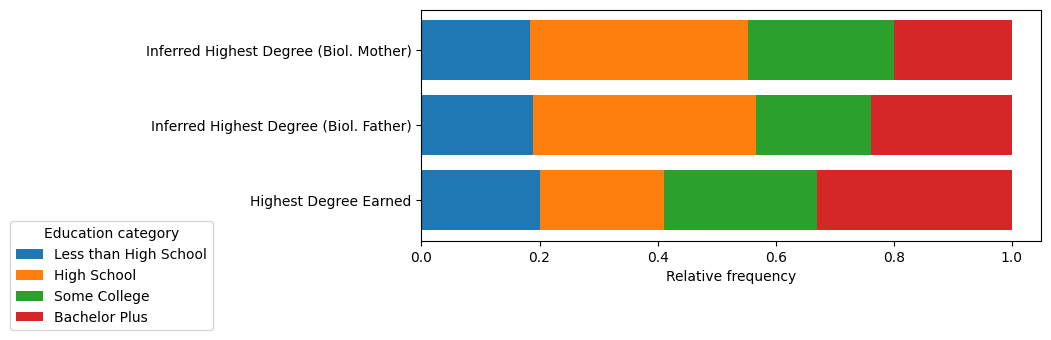

In [14]:
df = nlsy97_additional_vars_df.copy()
varnames = ['educ_cat', 'meduc_bio_cat', 'feduc_bio_cat']
plot_df = pd.DataFrame()
for varname in varnames:

    tmp = (
        df
            .loc[df['sample'].eq('Cross-sectional'), varname]
            .value_counts(normalize=True)
            .rename('proportion')
            .reset_index()
            .copy()
    )

    tmp['varname'] = varname 
    tmp['varlabel'] = short_varlabels_dict[varname]
    tmp['category'] = tmp[varname]
    tmp = tmp.drop(columns=varname)

    plot_df = pd.concat([plot_df, tmp], ignore_index=True)

plot_df = plot_df.sort_values(by=['varname', 'category']).reset_index(drop=True).copy()
plot_df['cumulative_proportion_below'] = plot_df.groupby('varname')['proportion'].cumsum() - plot_df['proportion']

categories = plot_df['category'].sort_values().drop_duplicates().to_list()

fig, ax = plt.subplots(figsize=(8, 3))

for category in categories:

    plot_df_cat = plot_df.loc[plot_df['category'].eq(category), :].sort_values(by=['varname']).copy()
    ax.barh(
        y=plot_df_cat['varlabel'],
        width=plot_df_cat['proportion'],
        left=plot_df_cat['cumulative_proportion_below'],
        label=category
    )

ax.set_xlabel('Relative frequency')
ax.legend(title='Education category', loc='center', bbox_to_anchor=(-0.5, -0.15))

Our main objective is intergenerational transmission of educational attainment.

##### Distribution of highest degree earned by parents' inferred highest degree earned.

Our target object of interest could be the probability distribution of highest degree earned conditional on each parent's inferred highest degree.

$$
\mathbb{P}[educ\_cat \ |\ \ meduc\_cat ]
$$

$$
\mathbb{P}[educ\_cat \ |\ \ feduc\_cat ]
$$

These are conditional probabilities. In our observed data, we can compute the corresponding conditional relative frequencies.


$$
\mathbb{P}[Y|X]
$$
where $Y$ is the `outcome variable` and $X$ is the `conditioning variable`


Statistical independence:
$$
\mathbb{P}[Y|X] =  \mathbb{P}[Y]
$$
strong measure of unrelatedness between variables

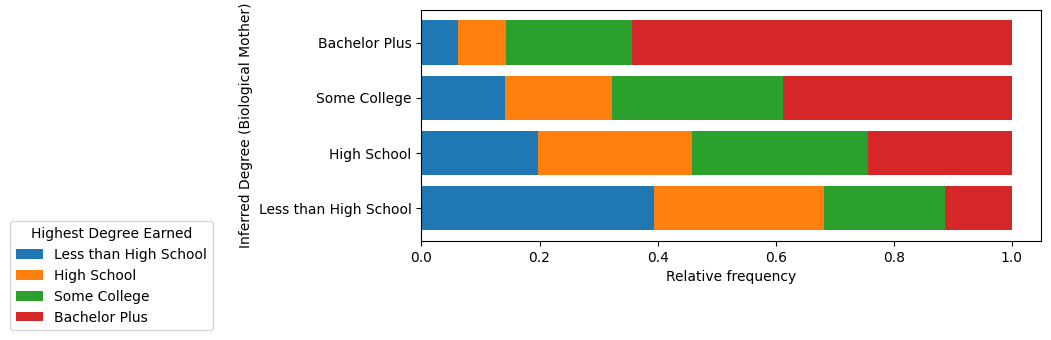

In [15]:
df = nlsy97_additional_vars_df.copy()
# conditioning variable parent educational attainment
conditioning_var = 'meduc_bio_cat'
# outcome variable child educational attainment
outcome_var = 'educ_cat'

df_subset = df.loc[df['sample'].eq('Cross-sectional'), [outcome_var, conditioning_var]].copy()

# conditional relative frequencies
plot_df = df_subset.groupby(conditioning_var).value_counts(subset=[outcome_var], normalize=True).reset_index().sort_values(by=[conditioning_var, outcome_var]).reset_index(drop=True).copy()

# cumulative proportions below -> where each bar segment begins 
plot_df['cumulative_proportion_below'] = (
    plot_df
        # within each value of parent education
        .groupby(conditioning_var)['proportion']
        # for each value V of child education
        # share of observations with level L < V 
        .cumsum() - plot_df['proportion']

)
# collecting categories / levels (distinct values) for the outcomes variable 
outcome_var_categories = plot_df[outcome_var].sort_values().drop_duplicates().to_list()

fig, ax = plt.subplots(figsize=(8, 3))

# iterating over the values of child education
for outcome_var_cat in outcome_var_categories:
   
    # restriction by outcome variable value
    plot_df_cat = plot_df.loc[plot_df[outcome_var].eq(outcome_var_cat), :].sort_values(by=[conditioning_var]).copy()
    
    ax.barh(
        # vertical axis: conditioning variable / parent education
        y=plot_df_cat[conditioning_var],
        # horizontal axis: stacked proportions of observations associated with distinct values of the outcome variable
        width=plot_df_cat['proportion'],
        left=plot_df_cat['cumulative_proportion_below'],
        label=outcome_var_cat
    )

ax.set_xlabel('Relative frequency')
ax.set_ylabel(long_varlabels_dict[conditioning_var])
# colour coding
ax.legend(title=short_varlabels_dict[outcome_var], loc='center', bbox_to_anchor=(-0.5, -0.15))




#### Intergenerational Income Mobility

Let us now investigate distribution of participants' 2023 income quintile (in the last observed year when participants are about 40 years old) conditional on the income quintile of their household income in 1997 (when participants are between 13 and 17 years old).


Adding income data from 2023 to the dataframe with the other variables:

In [16]:
# dataframe with income and hours
incomes_df = nlsy97_income_hours_all_df.copy()

incomes_df = (
    incomes_df
        # select rows (year = 2023) and columns (id, income, hours)
        .loc[incomes_df['year'].eq(2023), ['person_id', 'yinc', 'yhours']]
        # rename the income and hours variables
        .rename(columns={'yinc': 'yinc_2023', 'yhours': 'yhours_2023'})
        .copy()
)

# merging with the dataframe containing the other variables
incomes_df = pd.merge(left=nlsy97_additional_vars_df, # df with other variables
                      right=incomes_df, # df just created
                      on='person_id', # person id (uniqeness should normally be checked)
                      how='left') # left-join (keep all observations from left, add only matching observations from right)



Group observations by income rank into five equal groups (in ascending order)
 - by income rank in 1997 (parental income rank around the age of 15)
 - by income rank in 2023 (child income rank around the age of 40)



For both income variables, let us create five income quantile groups based on the income quantiles:
 - first quintile: $[Q(0), Q(0.2)]$ (between the 0% and the 20% point-quantile)
 - second quintile: $(Q(0.2), Q(0.4)]$ (between the 20% and the 40% point-quantile)
 - third quintile: $(Q(0.4), Q(0.6)]$ (between the 40% and the 60% point-quantile)
 - fourth quintile: $(Q(0.6), Q(0.8)]$ (between the 60% and the 80% point-quantile)
 - fifth quintile: $(Q(0.8), Q(1)]$ (between the 80% and the 100% point-quantile)


In [17]:
# We have variables hh_yinc_1997 (household income), yinc_2023 (labor income)
# Income concept is a little different
# Objective: hh_yinc_1997_Q (parent income quintile),  yinc_2023_Q (income quintile in 2023) 
 
df = incomes_df.copy()

dfs = {}

dfs['hh_yinc_1997'] = df.loc[df['hh_yinc_source_1997'].eq('Parent') & df['hh_yinc_1997'].notna() & df['sample'].eq('Cross-sectional'), ['person_id', 'hh_yinc_1997']].copy()
dfs['yinc_2023'] = df.loc[df['yinc_2023'].notna() & df['sample'].eq('Cross-sectional'), ['person_id', 'yinc_2023']].copy()
quintile_labels = ['1st Quintile', '2nd Quintile', '3rd Quintile', '4th Quintile', '5th Quintile']

for varname in ['hh_yinc_1997', 'yinc_2023']:

    df = dfs[varname].copy()
    
    # defining the 0%, 20%, 40%, 60%, 80%, 100% quantiles
    # to cut the distribution of income into five quintiles (equally sized intervals here)
    q0 = df[varname].min()
    q20 = df[varname].quantile(0.2)
    q40 = df[varname].quantile(0.4)
    q60 = df[varname].quantile(0.6)
    q80 = df[varname].quantile(0.8)
    q100 = df[varname].max()

    # defining the quintiles -> grouping observations into intervals
    incomes_df[varname + '_Q'] = pd.NA

    incomes_df.loc[incomes_df[varname].le(q20), varname + '_Q'] = quintile_labels[0]
    incomes_df.loc[incomes_df[varname].gt(q20) & incomes_df[varname].le(q40), varname + '_Q'] = quintile_labels[1]
    incomes_df.loc[incomes_df[varname].gt(q40) & incomes_df[varname].le(q60), varname + '_Q'] = quintile_labels[2]
    incomes_df.loc[incomes_df[varname].gt(q60) & incomes_df[varname].le(q80), varname + '_Q'] = quintile_labels[3]
    incomes_df.loc[incomes_df[varname].gt(q80), varname + '_Q'] = quintile_labels[4]

    incomes_df[varname + '_Q'] = pd.Categorical(incomes_df[varname + '_Q'], categories=quintile_labels, ordered=True)



Plotting.

Text(0, 0.5, 'Household Income Quintile in 1997')

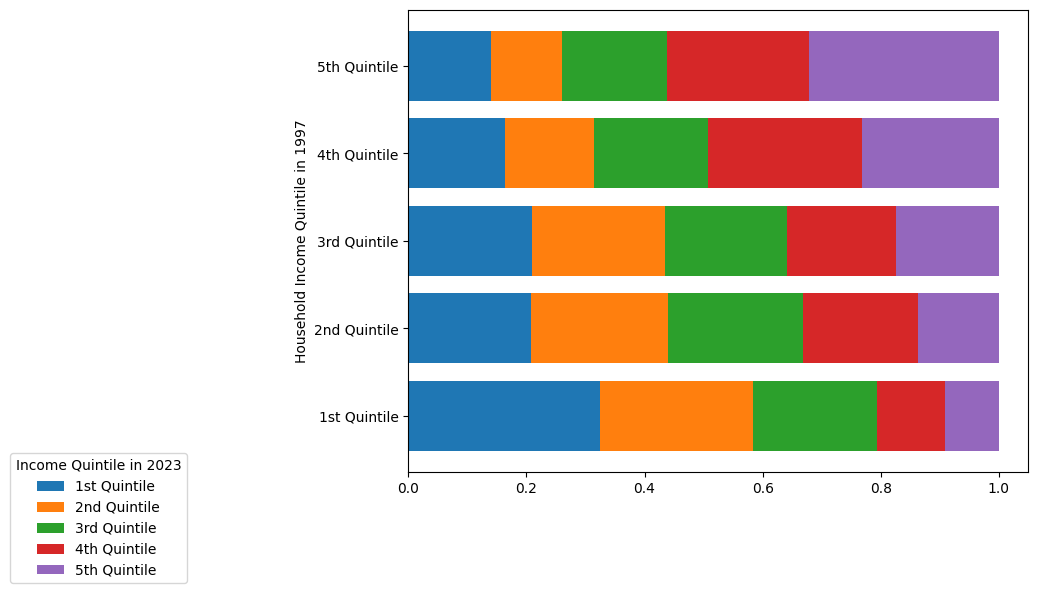

In [18]:
plot_df = incomes_df.copy()

plot_df = (
    plot_df
        # representative sub-sample
        .loc[plot_df['sample'].eq('Cross-sectional') &
             # hh income in 1997 is parent income  
             plot_df['hh_yinc_source_1997'].eq('Parent') &
             # non-missing observations for both income variables 
             plot_df['hh_yinc_1997'].notna() & 
             plot_df['yinc_2023'].notna(), 
             # selecting the variables
             ['hh_yinc_1997_Q', 'yinc_2023_Q']].copy()
)

conditioning_var = 'hh_yinc_1997_Q'
outcome_var = 'yinc_2023_Q'

# conditional relative frequencies
plot_df = (
    plot_df
        # within each of the conditioning variable (parent income quintile)
        .groupby(conditioning_var)
        # for each value of child income quintile
        # proportion of observations
        .value_counts(subset=[outcome_var], normalize=True)
        .reset_index()
        .sort_values(by=[conditioning_var, outcome_var])
        .reset_index(drop=True)


)

# computing conditional cumulative proportions
# within each parent quintile
# for each child quintile
plot_df['cumulative_proportion_below'] = (
    plot_df
        .groupby(conditioning_var)['proportion']
        .cumsum() 
        - plot_df['proportion']
)

# collecting distinct values of the outcome variable
outcome_var_categories = plot_df[outcome_var].sort_values().drop_duplicates().copy().to_list()

fig, ax = plt.subplots(figsize = (8,6))

for outcome_var_cat in outcome_var_categories:
    plot_df_cat = plot_df.loc[plot_df[outcome_var].eq(outcome_var_cat),:].sort_values(conditioning_var).reset_index(drop=True)

    ax.barh(y=plot_df_cat[conditioning_var],
            left=plot_df_cat['cumulative_proportion_below'],
            width=plot_df_cat['proportion'],
            label=outcome_var_cat)

ax.legend(title='Income Quintile in 2023', loc ='center', bbox_to_anchor = (-0.5,-0.1))
ax.set_ylabel('Household Income Quintile in 1997')



If child income-quintile was `statistically independent` from parent income-quintile, then we should see:
$$
\mathbb{P}[\text{child income quintile} | \text{parent income quintile}] = 20\%
$$

#### Conditional distribution under independence

Let us artificially reassign child income quintile to see how the distribution could look like if child income quintile was independent from parent income quintile:

Text(0, 0.5, 'Household Income Quintile in 1997')

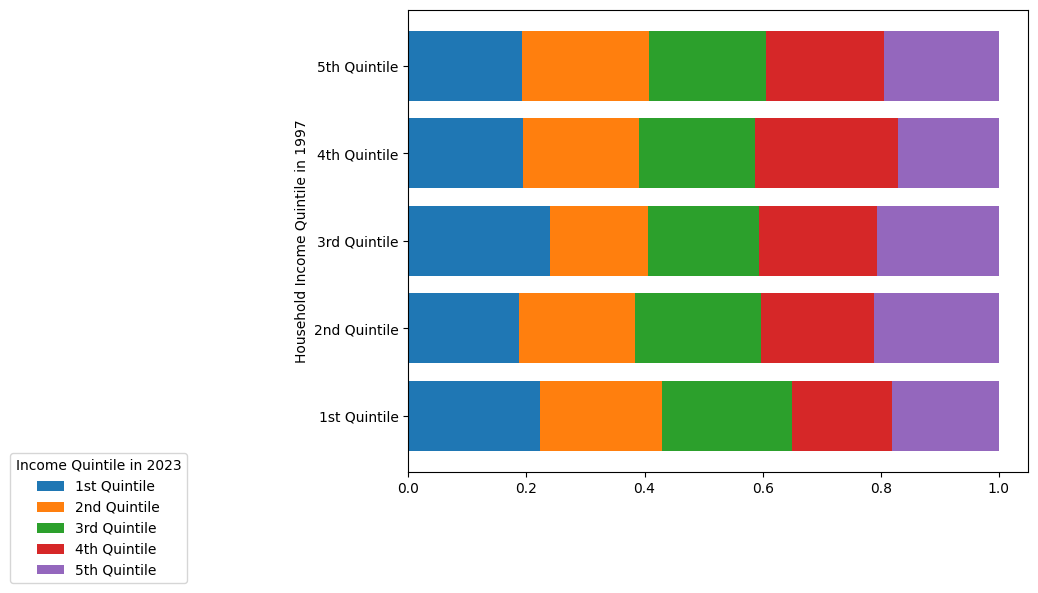

In [19]:
# Simulation -> complete independence

rng = np.random.default_rng(798312)

plot_df = incomes_df.copy()

plot_df = (
    plot_df
        # representative sub-sample
        .loc[plot_df['sample'].eq('Cross-sectional') &
             # hh income in 1997 is parent income  
             plot_df['hh_yinc_source_1997'].eq('Parent') &
             # non-missing observations for both income variables 
             plot_df['hh_yinc_1997'].notna() & 
             plot_df['yinc_2023'].notna(), 
             # selecting the variables
             ['hh_yinc_1997_Q', 'yinc_2023_Q']].copy()
)

# CREATING ARTIFICIAL DATA
# randomly reassign the income quintile around age 40
plot_df['yinc_2023_Q'] = rng.permutation(plot_df['yinc_2023_Q'])

conditioning_var = 'hh_yinc_1997_Q'
outcome_var = 'yinc_2023_Q'

# conditional relative frequencies
plot_df = (
    plot_df
        # within each of the conditioning variable (parent income quintile)
        .groupby(conditioning_var)
        # for each value of child income quintile
        # proportion of observations
        .value_counts(subset=[outcome_var], normalize=True)
        .reset_index()
        .sort_values(by=[conditioning_var, outcome_var])
        .reset_index(drop=True)


)

# computing conditional cumulative proportions
# within each parent quintile
# for each child quintile
plot_df['cumulative_proportion_below'] = (
    plot_df
        .groupby(conditioning_var)['proportion']
        .cumsum() 
        - plot_df['proportion']
)

# collecting distinct values of the outcome variable
outcome_var_categories = plot_df[outcome_var].sort_values().drop_duplicates().copy().to_list()

fig, ax = plt.subplots(figsize = (8,6))

for outcome_var_cat in outcome_var_categories:
    plot_df_cat = plot_df.loc[plot_df[outcome_var].eq(outcome_var_cat),:].sort_values(conditioning_var).reset_index(drop=True)

    ax.barh(y=plot_df_cat[conditioning_var],
            left=plot_df_cat['cumulative_proportion_below'],
            width=plot_df_cat['proportion'],
            label=outcome_var_cat)

ax.legend(title='Income Quintile in 2023', loc ='center', bbox_to_anchor = (-0.5,-0.1))
ax.set_ylabel('Household Income Quintile in 1997')



#### Test(s) of Independence between Parent Income Quintile and Child Income Quintile

In [20]:
df = incomes_df.copy()

df = (
    df
        # representative sub-sample
        .loc[df['sample'].eq('Cross-sectional') &
             # hh income in 1997 is parent income  
             df['hh_yinc_source_1997'].eq('Parent') &
             # non-missing observations for both income variables 
             df['hh_yinc_1997'].notna() & 
             df['yinc_2023'].notna(), 
             # selecting the variables
             ['hh_yinc_1997_Q', 'yinc_2023_Q']]
             .rename(columns={'hh_yinc_1997_Q': 'parent',
                              'yinc_2023_Q': 'child'})
             .copy()
)

observed_df = df.copy()

For the actually observed sample, we have the following actual empirical conditional distribution:

In [21]:
df = observed_df.copy()

df = (
    df
        # within each of the conditioning variable (parent income quintile)
        .groupby('parent')
        # for each value of child income quintile
        # proportion of observations
        .value_counts(subset=['child'], normalize=True)
        .reset_index()
        .sort_values(by=['parent', 'child'])
        .reset_index(drop=True)
        .copy()
)

# reshaping 
observed_distr_df = df.pivot(columns='child', index='parent', values='proportion').copy()
observed_distr_df

child,1st Quintile,2nd Quintile,3rd Quintile,4th Quintile,5th Quintile
parent,,,,,
1st Quintile,0.324042,0.259582,0.210801,0.114983,0.090592
2nd Quintile,0.207012,0.232053,0.228715,0.195326,0.136895
3rd Quintile,0.209622,0.225086,0.206186,0.185567,0.173540
4th Quintile,0.163551,0.151090,0.193146,0.260125,0.232087
5th Quintile,0.139303,0.121061,0.177446,0.240464,0.321725


After randomly permuting the child income quintiles, we obtain the following simulated empirical conditional distribution:

In [22]:
rng = np.random.default_rng(798312)

df = observed_df.copy()
# randomly reassign the child income quintile 
df['child'] = rng.permutation(df['child'])

df = (
    df
        # within each of the conditioning variable (parent income quintile)
        .groupby('parent')
        # for each value of child income quintile
        # proportion of observations
        .value_counts(subset=['child'], normalize=True)
        .reset_index()
        .sort_values(by=['parent', 'child'])
        .reset_index(drop=True)
        .copy()
)

one_permutation_df = df.copy()
one_permutation_distr_df = df.pivot(columns='child', index='parent', values='proportion').copy()

one_permutation_distr_df


child,1st Quintile,2nd Quintile,3rd Quintile,4th Quintile,5th Quintile
parent,,,,,
1st Quintile,0.222997,0.207317,0.219512,0.168990,0.181185
2nd Quintile,0.186978,0.196995,0.213689,0.190317,0.212020
3rd Quintile,0.240550,0.164948,0.189003,0.199313,0.206186
4th Quintile,0.194704,0.196262,0.196262,0.241433,0.171340
5th Quintile,0.192371,0.215589,0.197347,0.200663,0.194030


Unconditional probability = marginal probability

Under independence, the conditional distribution of child income quintiles should be identical across all parent income quintiles and equal to the unconditional (marginal) distribution:

$$
\mathbb{P}[\text{child quintile} \mid \text{parent quintile}]
=
\mathbb{P}[\text{child quintile}]
\qquad
\text{for all parent quintiles}
$$

The sample counterparts of the marginal probabilities $\mathbb{P}[\text{child quintile}]$ are the marginal relative frequencies observed in the data:

In [23]:
df = (
    observed_df.value_counts(subset=['child'], normalize=True)
        .reset_index()
        .sort_values(by=['child'])
        .reset_index(drop=True)
        .copy()
)


df = df.set_index('child').T.reset_index(drop=True).copy()
df = df.loc[df.index.repeat(5)].reset_index(drop=True).copy()
df.index = observed_distr_df.index.copy()
observed_unconditional_distr_df = df.copy()
observed_unconditional_distr_df

child,1st Quintile,2nd Quintile,3rd Quintile,4th Quintile,5th Quintile
parent,,,,,
1st Quintile,0.207,0.196333,0.203,0.201,0.192667
2nd Quintile,0.207,0.196333,0.203,0.201,0.192667
3rd Quintile,0.207,0.196333,0.203,0.201,0.192667
4th Quintile,0.207,0.196333,0.203,0.201,0.192667
5th Quintile,0.207,0.196333,0.203,0.201,0.192667


Statistical independence: strong degree/concept of unrelatedness  

Under the hypothesis of independence, the conditional distribution of child income quintiles should be similar across all parent income quintiles and should coincide with the unconditional (marginal) distribution of child income quintiles.

In the observed sample, the conditional distributions differ substantially across parent income quintiles.

However, even if parent and child income quintiles were truly independent in the population, random sampling variation could still generate conditional distributions that appear suggestive of statistical dependence.

Can we reject the hypothesis of independence? Is the observed conditional distribution so unusual that it would be unlikely to arise under independence?

To answer these questions more systematically, we need a measure of how far the observed conditional distribution deviates from what we would expect under independence.

Equivalently, we need a measure of how extreme the observed sample is relative to samples that could arise under the hypothesis of independence.

To quantify this extremeness, we choose a summary statistic that measures the degree of dependence.

One possibility is the Chi-Square Statistic, a summary measure of the discrepancy between observed joint frequencies and the joint frequencies implied by independence:

$$
T =
\sum_{\substack{i \in \text{Child Quintiles}\\ j \in \text{Parent Quintiles}}} \frac{(N_{i,j}(\text{observed}) - N_{i,j}(\text{expected under independence}))^2}{N_{i,j}(\text{expected under independence}) }
$$

where

- $N_{i,j}(\text{observed})$ is the observed frequency of observations with child income quintile $i$ and parent income quintile $j$;
- $N_{i,j}(\text{expected under independence})$ is the implied frequency of child income quintile $i$ among observations with parent income quintile $j$ under the hypothesis of independence.

Applying the definition of independence ($p_{i|j}(\text{expected under independence}) = p_{i}(\text{observed})$):

$$
N_{i,j}(\text{expected under independence}) = N_{j}(\text{observed}) \cdot p_{i|j}(\text{expected under independence}) = N_{j}(\text{observed}) \cdot p_{i}(\text{observed})
$$

where:
 - $N_{j}(\text{observed})$ is the observed frequency of parent income quintile $j$;
 - $p_{i|j}(\text{expected under independence})$ is the implied relative frequency of child income quintile $i$ among observations with parent income quintile $j$ under the hypothesis of independence;
 - $p_{i}(\text{observed})$ is the observed unconditional (or marginal) relative frequency of child income quintile $i$.

As a result, the Chi-Square Statistic becomes:

$$
T =
\sum_{\substack{i \in \text{Child Quintiles}\\ j \in \text{Parent Quintiles}}} \frac{(N_{i,j}(\text{observed}) - N_{j}(\text{observed}) \cdot p_{i}(\text{observed}))^2}{N_{j}(\text{observed}) \cdot p_{i}(\text{observed}) }
$$


In inferential statistics:

- the hypothesis of independence (in this example) is called the `null hypothesis`;
- the `summary measure` used to quantify `deviations from the null hypothesis` is called the `test statistic`;
- the `distribution of the test statistic` under the null hypothesis is called the `null distribution`.

There are two common approaches to approximate the null distribution:

- Simulation: Permutation Test
  - Approximate the distribution of the Chi-Square Statistic under independence through $R = 1000$ random permutations of child income quintiles.
  - For each permutation, recompute the Chi-Square Statistic.
  - The resulting empirical distribution approximates the null distribution.

- Large Sample Theory: Chi-Square Test
  - According to large-sample theory, the Chi-Square Statistic approximately follows a Chi-Square distribution under the null hypothesis of independence.
  - For a contingency table with $r$ rows and $c$ columns, the degrees of freedom are $(r-1)(c-1)$. The reason is that the row totals and column totals are fixed. Consider an $r \times c$ contingency table. If the row totals and column totals are known, then not all cell frequencies can vary freely. Once the frequencies in the first $(r-1)$ rows and $(c-1)$ columns have been determined, all remaining frequencies are automatically determined by the row and column totals. Therefore, the number of cells that can vary freely is $ (r-1)(c-1)$.
  - In our application, there are five parent income quintiles and five child income quintiles, implying $$(5-1)(5-1)=16$$ degrees of freedom such that under the null hypothesis of independence the Chi-Square Statistic approximately follows a Chi-Square Distribution with $16$ degrees of freedom:
$$
T \mid H_0 \overset{\text{\tiny approx.}}{\sim} \chi_{16}^2
$$


Let us first compute the observed value of the Chi-Square Statistic in the actual sample.

To do so, we need

- the observed joint frequencies $N_{i,j}$;
- the observed frequencies of parent income quintiles $N_j$;
- the observed marginal relative frequencies of child income quintiles $p_i$.

In [24]:
df = observed_df.copy()

# N(i,j) -> number of obs for each child quintile - parent quintile pair
# observed: N(i,j)

joint_frequencies_df = (
    df
        .value_counts(subset=['parent', 'child'], normalize=False) # frequencies (not relative frequencies)
        .reset_index()
        .sort_values(['parent', 'child'])
        .reset_index(drop=True)
        .rename(columns={'count': 'joint_frequency'}) # naming joint frequencies
        .copy()
)
joint_frequencies_df

# N(j) - number of observations/frequency for each parent quintile 
parent_frequencies_df = (
    df
        .value_counts(subset=['parent'])
        .reset_index()
        .sort_values(['parent'])
        .reset_index(drop=True)
        .rename(columns={'count': 'parent_frequency'})
        .copy()
)
parent_frequencies_df

# p(i) - relative frequency for each child quintile
child_relative_frequencies_df = (
    df
        .value_counts(subset=['child'], normalize=True)
        .reset_index()
        .sort_values(['child'])
        .reset_index(drop=True)
        .rename(columns={'proportion': 'child_relative_frequency'})
        .copy()
)
child_relative_frequencies_df

# merging the dataframes to have them together
df = pd.merge(left=joint_frequencies_df, right=parent_frequencies_df, on='parent', how='left')
df = pd.merge(left=df, right=child_relative_frequencies_df, on='child', how='left')

# expected joint frequencies (point comparison)
# N(j) * p(i)
df['expected_joint_frequency'] = df['parent_frequency'] * df['child_relative_frequency']
# applying the formula of the Chi-Square statistic
df['discrepancy'] = (df['joint_frequency'] - df['expected_joint_frequency']) ** 2 / df['expected_joint_frequency']
# summing the discrepancies
T_obs = df['discrepancy'].sum()

print('value of the Chi-Square Statistic for the observed sample: ', T_obs)



value of the Chi-Square Statistic for the observed sample:  240.6201289187383


Observed value: $\approx 240$, but how extreme is it under the null hypothesis of independence?

Let us simulate and compute the null distribution of our test statistic in our case:

In [25]:
rng = np.random.default_rng(798312)

R = 10000
T = np.zeros(R)

# fixed quantities
df = observed_df.copy()

# across all simulations N(j) stay the same
parent_frequencies_df = (
    df.value_counts(subset=['parent'])
      .reset_index()
      .rename(columns={'count': 'parent_frequency'})
)

# across all simulations p(i) stay the same
child_relative_frequencies_df = (
    df.value_counts(subset=['child'], normalize=True)
      .reset_index()
      .rename(columns={'proportion': 'child_relative_frequency'})
)

expected_df = pd.merge(
    parent_frequencies_df,
    child_relative_frequencies_df,
    how='cross'
)

# expected joint frequencies will stay the same across all simulations
expected_df['expected_joint_frequency'] = (
    expected_df['parent_frequency']
    * expected_df['child_relative_frequency']
)

for r in range(R):
    if (r % 1000) == 0: 
        print(f'{r/100} %')
    df_perm = observed_df.copy()
    df_perm['child'] = rng.permutation(df_perm['child'])


    # only thing that will vary across artificial random samples:
    # actual joint frequency in the artificial random sample  
    joint_frequencies_df = (
        df_perm.value_counts(subset=['parent', 'child'])
               .reset_index()
               .rename(columns={'count': 'joint_frequency'})
    )

    tmp = pd.merge(
        expected_df,
        joint_frequencies_df,
        on=['parent', 'child'],
        how='left'
    )

    tmp['joint_frequency'] = tmp['joint_frequency'].fillna(0)

    tmp['chi_square_contribution'] = (
        (tmp['joint_frequency'] - tmp['expected_joint_frequency']) ** 2
        / tmp['expected_joint_frequency']
    )

    T[r] = tmp['chi_square_contribution'].sum()

simulated_null_distr = pd.DataFrame({
    'sample_id': np.arange(1, R + 1),
    'T': T
})

0.0 %
10.0 %
20.0 %
30.0 %
40.0 %
50.0 %
60.0 %
70.0 %
80.0 %
90.0 %


In [26]:
simulated_null_distr

,sample_id,T
0,1,24.574899
1,2,17.512321
2,3,16.096645
3,4,23.459496
4,5,13.427971
...,...,...
9995,9996,19.264725
9996,9997,25.453119
9997,9998,9.336866
9998,9999,8.267184


P-value definition: Probability under the null hypothesis of obtaining a value of the Chi-Square Statistic at least as large as the observed value. 
Low p-value: If the null hypothesis of independence were true, the observed sample would be extremely unlikely.
Theoretical p-value: 0.0
The p-value may be displayed as 0.0 because it is extremely small and below numerical precision.


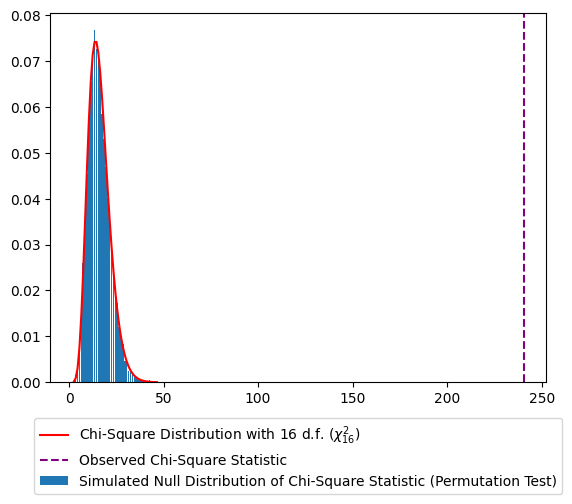

In [27]:
df = simulated_null_distr.copy()

# histogram
# bin width -> intervals
binwidth = 1
# binning observations in intervals of length binwidth= 1
bins = np.arange(start=np.floor(df['T'].min()), step=binwidth, stop=np.ceil(df['T'].max() + binwidth))
df['T_bin'] = pd.cut(df['T'], bins=bins)

# for each interval take the midpoint as the reference value
df['T_bin_midpoint'] = df['T_bin'].map(lambda x: x.mid) 

df = df.value_counts(subset=['T_bin_midpoint'], normalize=True).reset_index().sort_values('T_bin_midpoint').reset_index(drop=True)
df

from scipy.stats import chi2
chi2_pdf = chi2.pdf(df['T_bin_midpoint'], df=16) * binwidth

# bar plot
fig, ax = plt.subplots()
ax.bar(x=df['T_bin_midpoint'], height=df['proportion'], label='Simulated Null Distribution of Chi-Square Statistic (Permutation Test)')

ax.plot(df['T_bin_midpoint'], chi2_pdf, color='red', label=r'Chi-Square Distribution with 16 d.f. ($\chi^2_{16}$)')

# P-value: 
# Probability under the Null Hypothesis of obtaining a value of the statistic at least as extreme as its observed value (for the actual sample).
# If the Null Hypothesis is false, then the p-value is not actual probability 
# Hypothetical probability
print(
    'P-value definition: Probability under the null hypothesis of obtaining',
    'a value of the Chi-Square Statistic at least as large as the observed value.',
    '\nLow p-value: If the null hypothesis of independence were true,',
    'the observed sample would be extremely unlikely.'
)
theoretical_p_value = 1 - chi2.cdf(T_obs, df=16)
print('Theoretical p-value:', theoretical_p_value)
print('The p-value may be displayed as 0.0 because it is extremely small and below numerical precision.',)

ax.axvline(
    T_obs,
    linestyle='--',
    color = 'purple',
    label = 'Observed Chi-Square Statistic'
)

ax.legend(loc= 'center', bbox_to_anchor = (0.5, -0.2))




**Important remark:** The validity of the statistical inference methods discussed here relies on the assumption that the observed sample can be regarded as a random sample from a population.

#### Confidence Intervals for Gender Pay Gaps 

Let us turn to hourly income (hourly pay) by gender (here binary: women/men) in 2023.

One quantity of interest is the mean pay for each gender:

$$
\text{Population mean pay of women: }\ \ \ \ \mathbb{E}[hpay \mid gender=\text{Female}]
$$

$$
\text{Population mean pay of men: }\ \ \ \ \mathbb{E}[hpay \mid gender=\text{Male}]
$$

These quantities are called `conditional means` or `conditional expected values`.

The more general formulation:

$$
\mathbb{E}[hpay \mid gender]
$$

denotes the conditional mean of pay as a function of gender, also known as a `conditional mean function` (or `conditional expectation function`).

If the conditional mean pay is the same for both genders, i.e. if the conditional mean does not vary with gender, then hourly pay is said to be `mean independent` of gender:

$$
\text{Under mean independence: } \ \ \ \ \underbrace{\mathbb{E}[hpay \mid gender]}_{\text{conditional mean}} = \underbrace{\mathbb{E}[hpay]}_{\text{grand mean}}
$$

$$
\text{Under mean independence: } \ \ \ \ \mathbb{E}[hpay \mid gender=\text{Female}] = \mathbb{E}[hpay \mid gender=\text{Male}] = \underbrace{\mathbb{E}[hpay]}_{\text{grand mean}}
$$

This notion naturally parallels the concept of statistical independence while **not** being equivalent to it. 

Mean independence is a weaker condition than statistical independence. Statistical independence implies mean independence, but the converse is generally not true.

It is often useful to have a unitless measure of the gender pay gap:

$$
GPG = \frac{\mathbb{E}[hpay \mid gender=\text{Female}] - \mathbb{E}[hpay \mid gender=\text{Male}]}{\max\{\mathbb{E}[hpay \mid gender=\text{Female}],\mathbb{E}[hpay \mid gender=\text{Male}]\}}
$$

The above measure is:
 - symmetric
 - lies between $-1$ and $1$
 - negative values indicate a female disadvantage
 - positive values indicate a female advantage
 - a value of $0$ indicates no gender pay gap.

Following the so-called plug-in principle, we can compute the sample counterpart of the gender pay gap in our data:

$$
\widehat{GPG} = \frac{\overline{hpay}_{female} - \overline{hpay}_{male}}{\max\{\overline{hpay}_{female},\overline{hpay}_{male}\}}
$$

Like any sample statistic, $\widehat{GPG}$ varies from sample to sample.

Our objective is to learn about the population gender pay gap, $GPG$, using the observed sample.

More specifically, we would like to construct a `confidence interval`, i.e. a range of plausible values for the population gender pay gap.


Let us first select our sample and compute the observed gender pay gap.

This yields a single estimate, $\widehat{GPG}$, based on the particular sample available to us.

For this exercise, let us restrict attention to individuals who report working at least 1800 hours during the year. Consequently, the conditional means should be understood as
$$
\mathbb{E}[hpay \mid gender=\text{Female},\; yhours \geq 1800]
$$
and
$$
\mathbb{E}[hpay \mid gender=\text{Male},\; yhours \geq 1800].
$$

In [28]:
df = incomes_df.copy() 

df = (
    df.loc[df['sample'].eq('Cross-sectional') # representative sub-sample
           & df['yhours_2023'].ge(1800) # yearly hours >= 1800
           & df['yinc_2023'].notna() # non-missing income
           & df['yhours_2023'].notna() # non-missing hours
           & df['yhours_2023'].ne(0),:] # non-zero income
           .copy()
)

# hourly pay = yearly income / yearly hours 
df['hpay'] = df['yinc_2023'] / df['yhours_2023']

# conditional means (sample means) by gender
hpay_female = df.loc[df['gender'].eq('Female'), 'hpay'].mean()
hpay_male = df.loc[df['gender'].eq('Male'), 'hpay'].mean()

# applying the gender pay gap
observed_gpg = (hpay_female - hpay_male)/max(hpay_female, hpay_male)

observed_gpg

np.float64(-0.1741247582295128)

In our sample, the hourly pay of women is approximately 17% lower than that of men on average:

$$
\widehat{GPG}_{obs} \approx -17.4\%.
$$

Can we say anything about the population gender pay gap, $GPG$?

Put differently, if we were to draw a different random sample from the same population, how different would the estimated gender pay gap $\widehat{GPG}$ typically be? How narrow or wide is the range of values in which we would typically expect $\widehat{GPG}$ to lie?

When asking this question, the range we are interested in is called a `confidence interval`.

To construct a confidence interval with a given confidence level, our objective is to approximate the `sampling distribution` of the sample gender pay gap $\widehat{GPG}$.

The sample gender pay gap $\widehat{GPG}$ varies from sample to sample. It is therefore a random variable and has a probability distribution, its `sampling distribution`.

There are two common approaches to approximating the sampling distribution:

 - Large-sample theory:
   - use results such as the Central Limit Theorem to approximate the sampling distribution analytically;
 - Bootstrapping (simulation approach):
   - treat the observed sample as a proxy for the population;
   - approximate the sampling distribution through repeated resampling with replacement from the observed sample.

Let us implement the second approach here.
- Draw $R = 10000$ bootstrap samples, each of the same size $N$ as the original sample.
- Treat the observed sample as a proxy for the population and generate bootstrap samples through `independent draws with replacement`.
- Perform the resampling separately for each gender.
  - This is sometimes referred to as `stratified resampling`.
  - It preserves the sample sizes of the two gender groups across bootstrap samples.

Let us first initialise the observed sample by gender, which will serve as a stand-in for the population in the bootstrap procedure.

We also record the sample size of each gender group, as each bootstrap sample will contain the same number of women and men as the original sample.

In [29]:
# collecting the original sample for females
actual_sample_female = (
    df.loc[df['gender'].eq('Female') 
           & df['hpay'].notna(),
           'hpay']
        .copy()
)
actual_sample_female
N_female = actual_sample_female.shape[0]

# collecting the original sample for males
actual_sample_male = (
    df.loc[df['gender'].eq('Male') 
           & df['hpay'].notna(),
           'hpay']
           .copy()
)
N_male = actual_sample_male.shape[0]



Let us randomly draw one bootstrap sample and compute the gender pay gap for it.

A single bootstrap sample therefore mimics one possible alternative sample that could have been observed.

In [30]:
# pseudo random number generator
rng = np.random.default_rng(192384)

# numpy.random.choice()
# draw a random bootstrap sample for females
bootstrap_sample_female = rng.choice(
    # data from which to draw the observations randomly
    a=actual_sample_female,
    # how many observations to draw
    size=N_female,
    # with replacement
    replace=True
)
bootstrap_sample_male = rng.choice(
    a=actual_sample_male,
    size=N_male,
    replace=True
)

# mean hourly pay for women in this bootstrap sample
bootstrap_sample_female_hpay = bootstrap_sample_female.mean()
# mean hourly pay for men in this bootstrap sample
bootstrap_sample_male_hpay = bootstrap_sample_male.mean()
# applying the formula
bootstrap_sample_gpg = (
    (bootstrap_sample_female_hpay - bootstrap_sample_male_hpay)
    / max(bootstrap_sample_female_hpay, bootstrap_sample_male_hpay)
)

bootstrap_sample_gpg

np.float64(-0.23067528380404786)

In this artificial bootstrap sample, the hourly pay of women is 23% lower than the hourly pay of men.

Although artificial, this example illustrates the idea of sample-to-sample variation.

To approximate the sampling distribution of the gender pay gap, let us repeat this procedure for $R=10000$ bootstrap samples and compute the gender pay gap for each of them.

In [31]:
R = 10000

rng = np.random.default_rng(639281)

gpg_bootstrap = np.zeros(R)

for i in range(R):
    bootstrap_sample_female = rng.choice(
        a=actual_sample_female,
        size=N_female,
        replace=True
    )

    bootstrap_sample_male = rng.choice(
        a=actual_sample_male,
        size=N_male,
        replace=True
    )

    bootstrap_sample_female_hpay = bootstrap_sample_female.mean()
    bootstrap_sample_male_hpay = bootstrap_sample_male.mean()

    gpg_bootstrap[i] = (
        bootstrap_sample_female_hpay - bootstrap_sample_male_hpay
    ) / max(bootstrap_sample_female_hpay, bootstrap_sample_male_hpay)

In [32]:
gpg_bootstrap

array([-0.14433711, -0.16972639, -0.145305  , ..., -0.18549556,
       -0.19207941, -0.12823927], shape=(10000,))

Let us plot the bootstrap distribution:

In [33]:

# transforming the array with simulated gender pay gaps from bootstrapping
df = pd.DataFrame({'GPG_bootstrap': gpg_bootstrap})

# mu = observed_gpg
# sigma = df['GPG_bootstrap'].std(ddof=0)
# X = df['GPG_bootstrap'].sort_values(ascending=True).to_numpy()



# histogram
# values like -0.17, -0.21....
# binning observations with bin/interval width of 0.01
binwidth = 0.01
bins = np.arange(start=np.floor(df['GPG_bootstrap'].min() / binwidth) * binwidth, step=binwidth, stop=(np.ceil(df['GPG_bootstrap'].max() / binwidth) * binwidth + binwidth))

# cutting/binning the values using pd.cut()
df['GPG_bootstrap_bin'] = pd.cut(df['GPG_bootstrap'], bins=bins)

# let us take the midpoint for each bin/interval 
df['GPG_bootstrap_bin_midpoint'] = df['GPG_bootstrap_bin'].map(lambda x: x.mid)

# calculate the relative frequencies / proportions for each bin/interval
bootstrap_distr_df = df.value_counts(subset=['GPG_bootstrap_bin_midpoint'], normalize=True).reset_index().sort_values('GPG_bootstrap_bin_midpoint').reset_index(drop=True).copy()
bootstrap_distr_df


,GPG_bootstrap_bin_midpoint,proportion
0,-0.305,0.0001
1,-0.295,0.0000
2,-0.285,0.0003
3,-0.275,0.0005
4,-0.265,0.0019
5,-0.255,0.0056
6,-0.245,0.0087
7,-0.235,0.0215
8,-0.225,0.0352
9,-0.215,0.0572


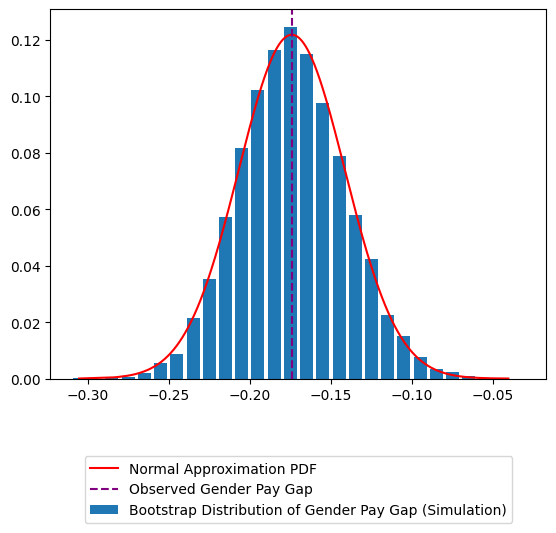

In [34]:

# transforming the array with simulated gender pay gaps from bootstrapping
df = pd.DataFrame({'GPG_bootstrap': gpg_bootstrap})


# corresponding normal distribution 
# two parameters: mean (mu), standard deviation (sigma)
mu = observed_gpg
# standard deviation from the bootstrap distribution (simulated artificial data)
sigma = df['GPG_bootstrap'].std(ddof=0)
# collecting the values from the bootstrap distribution (simulated artificial data)
X = df['GPG_bootstrap'].sort_values(ascending=True).to_numpy()



# histogram
# values like -0.17, -0.21....
# binning observations with bin/interval width of 0.01
binwidth = 0.01
bins = np.arange(start=np.floor(df['GPG_bootstrap'].min() / binwidth) * binwidth, step=binwidth, stop=(np.ceil(df['GPG_bootstrap'].max() / binwidth) * binwidth + binwidth))

# cutting/binning the values using pd.cut()
df['GPG_bootstrap_bin'] = pd.cut(df['GPG_bootstrap'], bins=bins)

# let us take the midpoint for each bin/interval 
df['GPG_bootstrap_bin_midpoint'] = df['GPG_bootstrap_bin'].map(lambda x: x.mid)

# calculate the relative frequencies / proportions for each bin/interval
bootstrap_distr_df = df.value_counts(subset=['GPG_bootstrap_bin_midpoint'], normalize=True).reset_index().sort_values('GPG_bootstrap_bin_midpoint').reset_index(drop=True).copy()
bootstrap_distr_df

# applying the corresponding normal distribution density function
from scipy.stats import norm
f_X = norm.pdf(X, loc=mu, scale=sigma) * binwidth


fig, ax = plt.subplots()
# bar plot for histogram
ax.bar(
    #bins/intervals on the x axis
    x=bootstrap_distr_df['GPG_bootstrap_bin_midpoint'], 
    #heights of the bars: relative frequencies
    height=bootstrap_distr_df['proportion'], 
    label='Bootstrap Distribution of Gender Pay Gap (Simulation)', 
    # width of the bars
    width=binwidth * 0.8)

# plotting the corresponding normal distribution density function
ax.plot(X, f_X, color='red', label=r'Normal Approximation PDF')

# vertical line at observed value of the gender pay gap
# should lie around the median/mean of the bootstrap distribution
# -> because the original sample is used for the bootstrapping
ax.axvline(
    observed_gpg,
    linestyle='--',
    color = 'purple',
    label = 'Observed Gender Pay Gap'
)

ax.legend(loc= 'center', bbox_to_anchor = (0.5, -0.3))


The bootstrap distribution appears to be approximately Normal.

In this example, this is not particularly surprising. The gender pay gap is constructed from differences and ratios of sample means, and the sample size is sufficiently large. As a result, large-sample theory suggests that the sampling distribution of the gender pay gap should be approximately Normal.

Let us now define a idence interval. Common choices for the confidence level are 90%, 95%, and 99%.

Let us use a 95% confidence level.

The corresponding 95% quantile interval is defined as follows:

 - the lower bound is the 2.5%-quantile of the bootstrap distribution;
 - the upper bound is the 97.5%-quantile of the bootstrap distribution.

By construction, 95% of the bootstrap estimates lie between these two bounds.

Let us add this confidence interval to our plot.

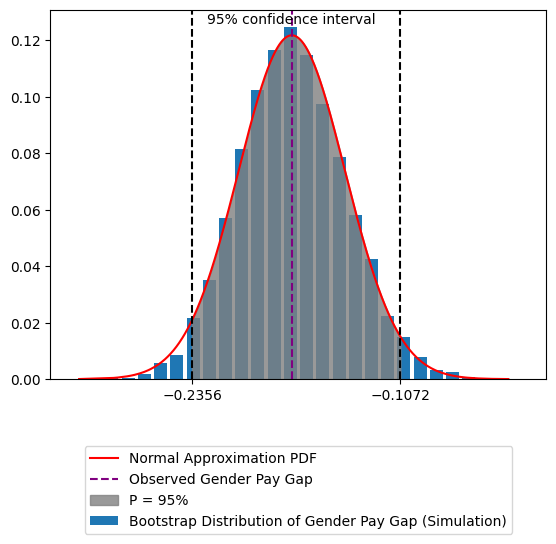

In [35]:

df = pd.DataFrame({'GPG_bootstrap': gpg_bootstrap})

mu = observed_gpg
sigma = df['GPG_bootstrap'].std(ddof=0)
X = df['GPG_bootstrap'].sort_values(ascending=True).to_numpy()

binwidth = 0.01
bins = np.arange(start=np.floor(df['GPG_bootstrap'].min() / binwidth) * binwidth, step=binwidth, stop=(np.ceil(df['GPG_bootstrap'].max() / binwidth) * binwidth + binwidth))
df['GPG_bootstrap_bin'] = pd.cut(df['GPG_bootstrap'], bins=bins)
df['GPG_bootstrap_bin_midpoint'] = df['GPG_bootstrap_bin'].map(lambda x: x.mid)
bootstrap_distr_df = df.value_counts(subset=['GPG_bootstrap_bin_midpoint'], normalize=True).reset_index().sort_values('GPG_bootstrap_bin_midpoint').reset_index(drop=True).copy()
bootstrap_distr_df


from scipy.stats import norm
f_X = norm.pdf(X, loc=mu, scale=sigma) * binwidth


fig, ax = plt.subplots()
ax.bar(x=bootstrap_distr_df['GPG_bootstrap_bin_midpoint'], height=bootstrap_distr_df['proportion'], label='Bootstrap Distribution of Gender Pay Gap (Simulation)', width=0.008)

ax.plot(X, f_X, color='red', label=r'Normal Approximation PDF')


ax.axvline(
    observed_gpg,
    linestyle='--',
    color = 'purple',
    label = 'Observed Gender Pay Gap'
)

ci_lower_bound = df['GPG_bootstrap'].quantile(0.025)
ci_upper_bound = df['GPG_bootstrap'].quantile(0.975)

ax.axvline(
    ci_lower_bound,
    linestyle='--',
    color = 'black'
)

ax.axvline(
    ci_upper_bound,
    linestyle='--',
    color = 'black'
)


ax.fill_between(
    x=X, 
    y1=f_X,
    where=(X <= ci_upper_bound) & (X >= ci_lower_bound),
    label = 'P = 95%',
    alpha = 0.8,
    color = 'gray'
)

ax.xaxis.set_ticks(ticks = [ci_lower_bound, ci_upper_bound])

ax.text(
    x=observed_gpg,
    y=0.126,
    s=f'95% confidence interval',
    ha='center',
    color='black'
)

ax.legend(loc= 'center', bbox_to_anchor = (0.5, -0.3))


In [36]:
print('Bootstrap 95% CI: ', ci_lower_bound, ',', ci_upper_bound)
print('Normal Approximation 95% CI: ', norm.ppf(0.025, loc=mu, scale=sigma), ',', norm.ppf(0.975, loc=mu, scale=sigma))


Bootstrap 95% CI:  -0.23560025171144958 , -0.10717918345179196
Normal Approximation 95% CI:  -0.2383113666893456 , -0.10993814976967999


Gender pay gaps by education groups:

In [37]:
df = incomes_df.copy() 

df = df.loc[df['sample'].eq('Cross-sectional') & df['yhours_2023'].ge(1800) & df['yinc_2023'].notna() & df['yhours_2023'].notna() & df['yhours_2023'].ne(0),:].copy()

df['hpay'] = df['yinc_2023'] / df['yhours_2023']

degree_var = 'educ_cat'

df = df.groupby(['gender', degree_var]).agg(hpay_mean = ('hpay', 'mean'), count=('hpay', 'size')).reset_index().sort_values(['gender', degree_var]).reset_index(drop=True).copy()


In [38]:


df_female = df.loc[df['gender'].eq('Female'), [degree_var, 'hpay_mean', 'count']].rename(columns={'hpay_mean': 'hpay_mean_female',
                                                                                                'count': 'count_female'})
df_male = df.loc[df['gender'].eq('Male'), [degree_var, 'hpay_mean', 'count']].rename(columns={'hpay_mean': 'hpay_mean_male',
                                                                                                'count': 'count_male'})
df_wide = pd.merge(left = df_female, right=df_male, on=degree_var)
df_wide = df_wide.sort_values(degree_var)
df_wide

df_wide['GPG'] = (df_wide['hpay_mean_female'] - df_wide['hpay_mean_male']) / df_wide[['hpay_mean_female', 'hpay_mean_male']].max(axis=1)

df_wide


,educ_cat,hpay_mean_female,count_female,hpay_mean_male,count_male,GPG
0,Less than High School,23.377997,92,26.322743,203,-0.111871
1,High School,21.469911,115,33.675825,263,-0.362453
2,Some College,28.00939,210,39.497874,307,-0.290863
3,Bachelor Plus,46.204412,436,63.549731,372,-0.272941


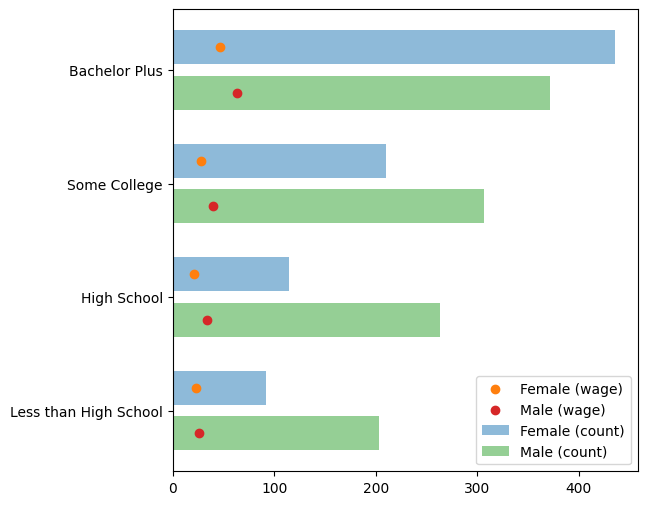

In [39]:
degree_order = df_wide[degree_var].dropna().sort_values().unique()
degree_ranks = np.arange(len(degree_order))
degree_to_y = {degree_order[i]: i for i in degree_ranks}

df_wide['y'] = df_wide[degree_var].map(degree_to_y).astype(float)

fig, ax = plt.subplots(figsize=(6,6))

dodge = 0.2

ax.barh(y=df_wide['y'] + dodge, height=0.3, width=df_wide['count_female'], alpha=0.5, label= 'Female (count)')
ax.scatter(y=df_wide['y'] + dodge, x=df_wide['hpay_mean_female'], label='Female (wage)')

ax.barh(y=df_wide['y'] - dodge, height=0.3, width=df_wide['count_male'], alpha=0.5, label= 'Male (count)')
ax.scatter(y=df_wide['y'] - dodge, x=df_wide['hpay_mean_male'], label='Male (wage)')


ax.set_yticks(ticks=degree_ranks, labels=degree_order)
#ax.set_yticklabels()

ax.legend()



#### Correlation between hourly wages and test score percentiles


For this section, we need the dataframe `incomes_df` containing both income and hours worked in 2023, as well as the time-invariant variables from `nlsy97_additional_vars_df`.

Let us again construct the hourly pay variable.

In [40]:
df = incomes_df.copy()

valid = (
    # non-missing pay and hours
    df['yinc_2023'].notna() &
    df['yhours_2023'].notna() &
    # non-zero pay and hours
    df['yinc_2023'].ne(0) &
    df['yhours_2023'].ne(0)
)
# hourly pay
df['hpay'] = np.where(valid,
                      df['yinc_2023'] / df['yhours_2023'],
                      pd.NA)

df = df.convert_dtypes()
inc_df = df.copy()



**ASVAB test scores**

In the first round of the NLSY97 survey, respondents completed the ASVAB (*Armed Services Vocational Aptitude Battery*), a standardized aptitude test.

In the dataframe `nlsy97_additional_vars_df`, the variable `ASVAB_score` contains ASVAB percentile scores multiplied by 1000. For example:

- `ASVAB_score = 50000` corresponds to the 50th percentile,
- `ASVAB_score = 75000` corresponds to the 75th percentile,
- `ASVAB_score = 90000` corresponds to the 90th percentile.

For convenience, we divide the variable by 1000 and work directly with percentile scores ranging from 0 to 100.

In [41]:
df = inc_df.copy() 
print('minimum:', df['ASVAB_score'].min(), ' maximum:', df['ASVAB_score'].max())

minimum: 0  maximum: 100000


Let us create a variable containing the ASVAB percentiles, i.e. without the multiplication by 1000:

In [42]:
df['ASVAB_pct'] = df['ASVAB_score'] / 1000
df = df.convert_dtypes()
inc_df = df.copy()

Let us verify that `ASVAB_pct` indeed contains percentile ranks.

Since percentile ranks are approximately uniformly distributed, we expect the distribution of `ASVAB_pct` to be close to uniform in the representative sample (`sample == 'Cross-sectional'`).

if ASVAB_pct is a percentile, then in the representative sample about 1% of individuals should belong to each percentile
--> uniform distribution of ASVAB_pct in the representative sample 

In [43]:
df = inc_df.copy()
df['ASVAB_pct']

0        45.07
1       58.483
2       27.978
3       37.012
4         <NA>
         ...  
8979    12.716
8980    27.785
8981    96.478
8982     61.58
8983    71.549
Name: ASVAB_pct, Length: 8984, dtype: Float64

<BarContainer object of 101 artists>

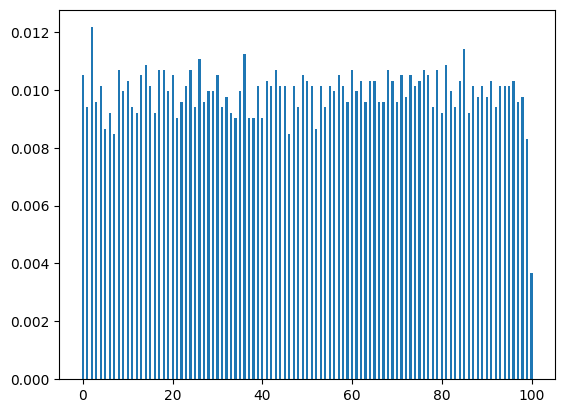

In [44]:
df = inc_df.copy()

# binning the observations by percentile 
# rounding down to the nearest integer 
# largest integer below
# 2.34 --> 2  np.floor()
# 17.87 --> 17
df['ASVAB_pct_bin'] = np.floor(df['ASVAB_pct'])
df['ASVAB_pct_bin'].dtype

df_sum = (
    df
        .loc[df['sample'].eq('Cross-sectional')] # representative sample
        # proportions / relative frequencies for each percentile bin 
        .value_counts(subset=['ASVAB_pct_bin'], normalize=True)  
        .reset_index()
        .sort_values('ASVAB_pct_bin')
        .reset_index(drop = True)
        .copy()
)

fig, ax = plt.subplots()

ax.bar(x=df_sum['ASVAB_pct_bin'], height=df_sum['proportion'], width=0.5)

About 1% of observations belong to each percentile rank bin for the representative sample.

hourly pay, ASVAB (test score) percentile rank

##### Scatterplot

For continuous variables, a scatterplot is a natural first step to visualise the relationship between two (or three) variables.

Let us create a scatterplot of hourly pay on the vertical (y) axis and ASVAB percentile on the horizontal (x) axis.

Text(0.5, 0, 'ASVAB test score percentile rank in 1997')

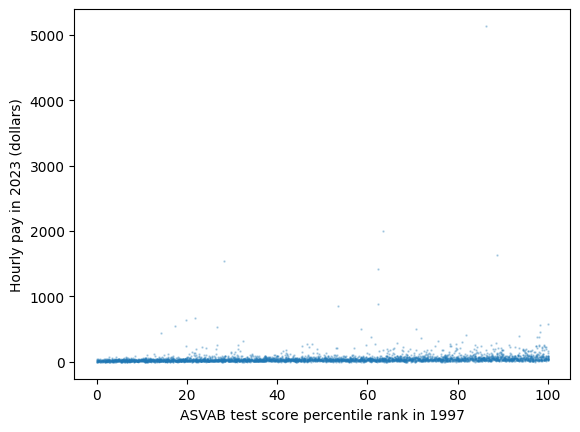

In [45]:
df = inc_df.copy()

fig, ax = plt.subplots()
# scatter plot
# test score percentile rank on the horizontal axis 
# hourly pay on the vertical axis
ax.scatter(x=df['ASVAB_pct'], y=df['hpay'], s=0.5, alpha=0.3)

ax.set_ylabel('Hourly pay in 2023 (dollars)')
ax.set_xlabel('ASVAB test score percentile rank in 1997')

The scatter plot is difficult to interpret because the distribution of hourly pay is strongly right-skewed.

The extreme observations may reflect reporting errors (for example, incorrectly reported hours worked) or genuine high-income observations.

For right-skewed variables, it is often useful to take the natural logarithm and work with the transformed variable.

In [46]:
df = inc_df.copy()
# natural logarithm of hourly pay
df['log_hpay'] = np.where(
    # if hourly pay non-missing and positive
    df['hpay'].gt(0) & df['hpay'].notna(),
    # take natural log
    np.log(df['hpay']),
    # otherwise: missing value 
    pd.NA) 
df = df.convert_dtypes()
inc_df = df.copy()

Let us look at the scatterplot of log hourly pay and the ASVAB test score percentile:

Text(0.5, 0, 'ASVAB test score percentile rank in 1997')

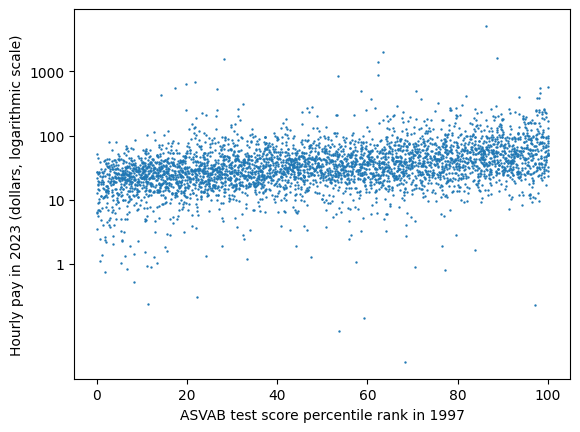

In [47]:
df = inc_df.copy()

fig, ax = plt.subplots()

ax.scatter(x=df['ASVAB_pct'], y=df['log_hpay'], s=0.5)

# ticks / labels for vertical y-axis 
# set of values of hourly pay to show on the y-axis
y_tickvalues = np.array([1,10,100,1000])

# corresponding actual values for log hourly pay
y_tickvalues_log = np.log(y_tickvalues) 

# corresponding labels as hourly pay 
y_tickvalues_str = y_tickvalues.astype(str)

ax.yaxis.set_ticks(ticks=y_tickvalues_log, labels=y_tickvalues_str)


ax.set_ylabel('Hourly pay in 2023 (dollars, logarithmic scale)')
ax.set_xlabel('ASVAB test score percentile rank in 1997')



Visually, in the scatter plot, there seems to be a roughly linear relationship between log hourly pay and the ASVAB percentile rank.

Let us plot the conditional mean of log hourly pay as a function of the ASVAB percentile rank.

Text(0.5, 0, 'ASVAB test score percentile rank in 1997')

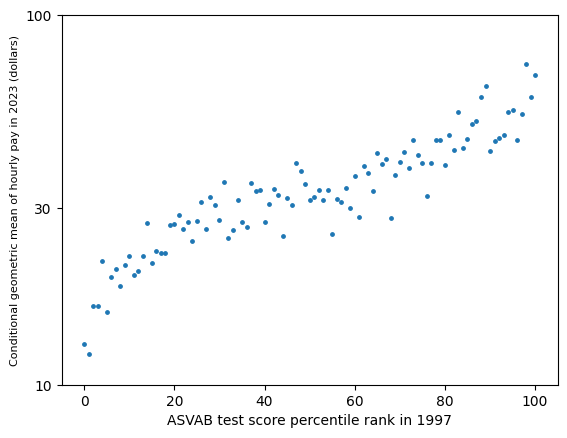

In [48]:
df = inc_df.copy()

# binning the observations by test score percentile bin
# rounding down to the nearest integer 
# largest integer below
# 2.34 --> 2  np.floor()
# 17.87 --> 17
df['ASVAB_pct_bin'] = np.floor(df['ASVAB_pct'])

# conditional mean log hourly pay, equivalent of E[log_hpay|ASVAB_pct_bin]
plot_df = (
    df
        # grouping by percentiles
        .groupby(by='ASVAB_pct_bin')
        # taking the mean of log hourly pay 
        .agg(mean_log_hpay = ('log_hpay', 'mean'))
        # formatting
        .reset_index()
        .copy()
)
plot_df = plot_df.convert_dtypes()
plot_df
fig, ax = plt.subplots()

ax.scatter(x=plot_df['ASVAB_pct_bin'], y=plot_df['mean_log_hpay'], s=6)

y_tickvalues = np.array([10,30,100])
y_tickvalues_log = np.log(y_tickvalues) 
y_tickvalues_str = y_tickvalues.astype(str)
ax.yaxis.set_ticks(ticks=y_tickvalues_log, labels=y_tickvalues_str)

ax.set_ylabel('Conditional geometric mean of hourly pay in 2023 (dollars)', fontsize=8)
ax.set_xlabel('ASVAB test score percentile rank in 1997')



Side note:

Why is the y-axis interpreted as a geometric mean?

The plotted values are conditional means of log hourly pay. The y-axis labels convert these values back to dollars by applying the exponential function.

Therefore, the population quantity corresponding to the y-axis labels is:
$$
G(p) = \exp(\mathbb{E}[\ln(hpay) \mid ASVAB\_pct\_bin = p])
$$
which is the conditional geometric mean of hourly pay.

(Therefore, a value of $G(p)=30$ should be interpreted as a conditional geometric mean hourly pay of 30 dollars.)

The conditional mean plot confirms the positive relationship between log hourly pay and the ASVAB test score percentile rank.

The relationship is not linear.

But is there a way to quantify how close the relationship is to a straight line?

This question leads to the notion of correlation.

##### Pearson's correlation coefficient

So far, we have seen two notions of statistical relatedness: statistical dependence/independence and mean dependence/independence.

Correlation provides a third notion of statistical relatedness.

**Covariance**

A common measure of statistical association is the covariance.

Covariance captures the direction of linear association between variables and plays a central role in the definition of correlation.

The covariance between the random variables $Y$ and $X$ is the `expected value of the product of their deviations from their respective expected values`:

$$
Cov(Y,X) = \mathbb{E}[(Y - \mathbb{E}[Y])\cdot (X - \mathbb{E}[X])]
$$

The finite-sample counterpart is defined analogously as the `sample mean of the product of deviations from the respective sample means`:

$$
Cov(y,x) = \frac{1}{N} \sum_{i \in Sample} (y_i - \bar{y})\cdot (x_i - \bar{x})
$$

The covariance can be viewed as a generalisation of the variance to pairs of variables. In particular, the covariance of a variable with itself is equal to its variance:

$$
Cov(Y,Y) = Var(Y) \ \ \ \ \ \ Cov(X,X) = Var(X)
$$

Let us compute the covariance between log hourly pay in 2023 and ASVAB percentile ranks.

The `np.cov()` function from NumPy returns a variance-covariance matrix. For two variables, $Y$ and $X$, this matrix is given by:

$$
\begin{pmatrix}
Cov(Y,Y) & Cov(Y,X)
\\
Cov(Y,X) & Cov(X,X)
\end{pmatrix}
=
\begin{pmatrix}
Var(Y) & Cov(Y,X)
\\
Cov(Y,X) & Var(X)
\end{pmatrix}
$$

The diagonal elements correspond to the variances of the individual variables, while the off-diagonal elements correspond to their covariance.

In [49]:
df = inc_df.copy()
# Y, X
# Y - outcome variable
# X - conditioning variable  
varnames = ['log_hpay', 'ASVAB_pct']

df = df[varnames].dropna().copy()
df = df.astype(float)

y = df[varnames[0]].copy()
x = df[varnames[1]].copy()

# applying the formula of covariance
# mean of product of deviations from the respective means
cov_by_hand = ((y - y.mean()) * (x - x.mean())).mean() 
 
cov_mat = np.cov(
    df[varnames],
    rowvar=False,
    ddof=0
)
cov_df = pd.DataFrame(
    cov_mat,
    columns=varnames,
    index=varnames
)

print('Variance-covariance matrix:\n', 
      cov_df,
      f'\n\nVariance {varnames[0]}:',
      np.var(df[varnames[0]], ddof=0), 
      f'\n\nVariance {varnames[1]}:',
      np.var(df[varnames[1]], ddof=0),
      '\n\nCovariance computed "by hand":',
      cov_by_hand)





Variance-covariance matrix:
            log_hpay   ASVAB_pct
log_hpay   0.706000    9.080352
ASVAB_pct  9.080352  837.921958 

Variance log_hpay: 0.7060002322374855 

Variance ASVAB_pct: 837.9219575030478 

Covariance computed "by hand": 9.080352316449858


What is the issue with the covariance? Let us look at the units.

The covariance involves taking the mean of the `product of deviations of the variables` from their respective means. 

The covariance is therefore expressed in units that correspond to the product of the units of each of the two variables.

In the present case, the covariance is expressed in log hourly pay units times percentile ranks.

If a variable is transformed, the units and the covariance will change.

The covariance is difficult to compare across different contexts.

This echoes a little the issue of squared units encountered in the case of the variance.

**Correlation: A unitless measure of linear statistical relatedness between two variables.**

Also called Pearson's correlation coefficient.

To obtain a unitless measure, the correlation simply divides the covariance by the standard deviations of the two variables:

$$
Corr(Y,X) = \frac{Cov(Y,X)}{SD(Y)\cdot SD(X)}
$$

The idea is similar to the idea of standardisation.

The correlation always lies between -1 and +1: 
  - -1 indicating perfect negative linear association (along a downward sloping straight line)
  - +1 indicating perfect positive linear association (along an upward sloping straight line)
  - 0 indicating no linear association

Let us compute the correlation between log hourly pay and the ASVAB percentile rank.

The `np.corrcoef()` method returns a matrix of correlation coefficients. In line with the logic of the variance-covariance matrix, for two variables $X$ and $Y$, this matrix is given by:

$$
\begin{pmatrix}
Corr(Y,Y) & Corr(Y,X)
\\
Corr(Y,X) & Corr(X,X)
\end{pmatrix} = 
\begin{pmatrix}
1 & Corr(Y,X)
\\
Corr(Y,X) & 1
\end{pmatrix}
$$
The diagonal elements are all $1$ because every variable is by construction perfectly positively correlated with itself.

In [50]:
df = inc_df.copy()
varnames = ['log_hpay', 'ASVAB_pct']
df = df[varnames].dropna().copy()
df = df.astype(float)


y = df[varnames[0]].copy()
x = df[varnames[1]].copy()

# applying the formula of covariance
cov_by_hand = ((y - y.mean()) * (x - x.mean())).mean()
# applying the formula of correlation 
corr_by_hand = cov_by_hand / (x.std(ddof=0) * y.std(ddof=0))

print('Correlation coefficient matrix:\n',
      np.corrcoef(y,x),
      '\n\nCorrelation coefficient calculated "by hand":\n',
      corr_by_hand)


Correlation coefficient matrix:
 [[1.         0.37333482]
 [0.37333482 1.        ]] 

Correlation coefficient calculated "by hand":
 0.3733348152926623


Let us add a third variable: educational attainment.

Let us look at 
 - whether the relationship between log hourly pay and the ASVAB percentile rank is closer to linear among individuals with a Bachelor's degree or among individuals without a Bachelor's degree;
 - whether the correlation between the two variables is stronger or weaker within these groups.

Let us start with the same scatterplots and empirical conditional mean functions as before, but this time separately for each group.

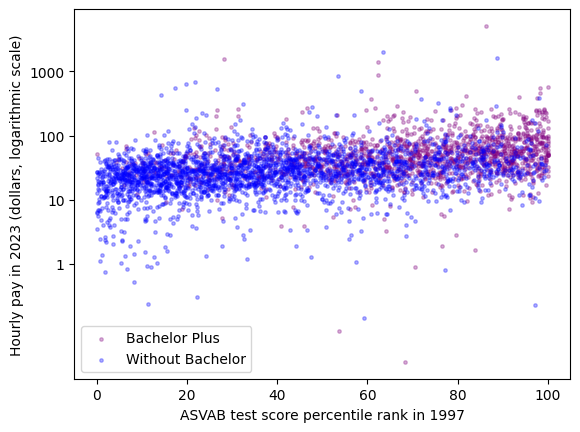

In [51]:
df = inc_df.copy()

# sample with Bachelor
bachelorplus = df.loc[df['educ_cat'].eq('Bachelor Plus'),:]
# sample without Bachelor
withoutbachelor = df.loc[df['educ_cat'].ne('Bachelor Plus') & df['educ_cat'].notna(),:]

fig, ax = plt.subplots()
# Bachelor purple
ax.scatter(x=bachelorplus['ASVAB_pct'], y=bachelorplus['log_hpay'], s=6, color='purple', label='Bachelor Plus', alpha=0.3)
# without Bachelor blue
ax.scatter(x=withoutbachelor['ASVAB_pct'], y=withoutbachelor['log_hpay'], s=6, color='blue', label='Without Bachelor', alpha=0.3)

y_tickvalues = np.array([1,10,100,1000])
y_tickvalues_log = np.log(y_tickvalues) 
y_tickvalues_str = y_tickvalues.astype(str)
ax.yaxis.set_ticks(ticks=y_tickvalues_log, labels=y_tickvalues_str)

ax.set_ylabel('Hourly pay in 2023 (dollars, logarithmic scale)')
ax.set_xlabel('ASVAB test score percentile rank in 1997')
ax.legend()

This plot is too crowded. Let us look at the conditional mean plot.

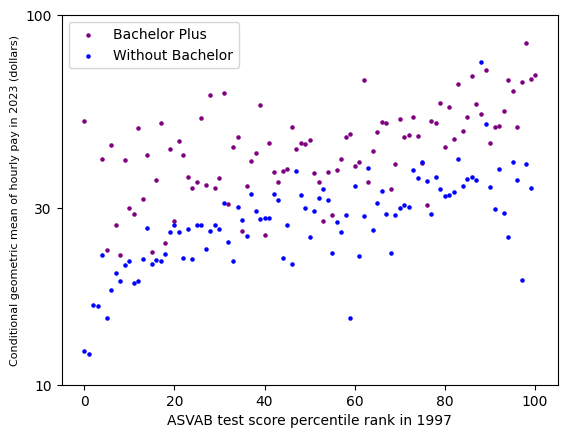

In [52]:
df = inc_df.copy()

df['ASVAB_pct_bin'] = np.floor(df['ASVAB_pct'])

bachelorplus = df.loc[df['educ_cat'].eq('Bachelor Plus'),:]
withoutbachelor = df.loc[df['educ_cat'].ne('Bachelor Plus') & df['educ_cat'].notna(),:]

bachelorplus = (
    # within the education group
    bachelorplus
    #grouping by percentile rank bin
        .groupby(by='ASVAB_pct_bin')
    # conditional mean of log hourly pay 
        .agg(mean_log_hpay = ('log_hpay', 'mean'))
        .reset_index()
        .convert_dtypes()
)

withoutbachelor = withoutbachelor.groupby(by='ASVAB_pct_bin').agg(mean_log_hpay = ('log_hpay', 'mean')).reset_index().convert_dtypes()

fig, ax = plt.subplots()

ax.scatter(x=bachelorplus['ASVAB_pct_bin'], y=bachelorplus['mean_log_hpay'], s=5, color='purple', label='Bachelor Plus')

ax.scatter(x=withoutbachelor['ASVAB_pct_bin'], y=withoutbachelor['mean_log_hpay'], s=5, color='blue', label='Without Bachelor')


y_tickvalues = np.array([10,30,100])
y_tickvalues_log = np.log(y_tickvalues) 
y_tickvalues_str = y_tickvalues.astype(str)
ax.yaxis.set_ticks(ticks=y_tickvalues_log, labels=y_tickvalues_str)

ax.set_ylabel('Conditional geometric mean of hourly pay in 2023 (dollars)', fontsize=8)
ax.set_xlabel('ASVAB test score percentile rank in 1997')
ax.legend()


There is non-linearity in both groups.

The group without a Bachelor's degree seems to show a somewhat stronger positive relationship, primarily at lower ASVAB percentile ranks.

Let us look at the correlation coefficient by group.

In [53]:
df = inc_df.copy()
varnames = ['log_hpay', 'ASVAB_pct']
df = df[varnames + ['educ_cat']].dropna().copy()

bpl = df.loc[df['educ_cat'].eq('Bachelor Plus'),varnames].copy()
wob = df.loc[df['educ_cat'].ne('Bachelor Plus') & df['educ_cat'].notna(),varnames].copy()

bpl = bpl.astype(float)
wob = wob.astype(float)


bpl_y = bpl[varnames[0]]
bpl_x = bpl[varnames[1]]

bpl_corr = ((bpl_y - bpl_y.mean()) * (bpl_x - bpl_x.mean())).mean() / (bpl_y.std(ddof=0) * bpl_x.std(ddof=0)) 

wob_y = wob[varnames[0]]
wob_x = wob[varnames[1]]

wob_corr = ((wob_y - wob_y.mean()) * (wob_x - wob_x.mean())).mean() / (wob_y.std(ddof=0) * wob_x.std(ddof=0)) 

print('Correlation among individuals with Bachelor Plus:\n',
      bpl_corr,
      '\nCorrelation among individuals without Bachelor:\n',
      wob_corr)

Correlation among individuals with Bachelor Plus:
 0.2224001401706829 
Correlation among individuals without Bachelor:
 0.25187496302482604


corr of test score pct rank with log_hpay
 -> stronger in the aggregate

part of this correlation can be explained by
 -> positive correlation between test score percentile rank and having a Bachelor's degree
 -> positive correlation between having a Bachelor's degree and log hourly pay 

these are only correlations

Two remarks:
 1. The correlation within each group is weaker than the correlation in the aggregate sample (0.37).
 2. The correlation is slightly higher among individuals without a Bachelor's degree (0.252) than among individuals with a Bachelor's degree (0.222). However, the difference is relatively small.

Is Remark 1 surprising? Not necessarily.

Part of the positive correlation between hourly pay and test score percentile ranks may be explained by: 
 - the positive relationship between hourly pay and having a Bachelor's degree (as seen in the conditional mean plot); 
 - the positive relationship between obtaining a Bachelor's degree and test score percentile ranks (as seen in the scatter plot).

Important caution: these are still only correlations, including the correlations computed within groups. There is a difference between "explained by" and "causally related to".
 - For example, there may be many reasons why individuals with higher test scores are more likely to obtain a Bachelor's degree.



**Uncorrelatedness**

Two variables, $Y$ and $X$ are said to be uncorrelated when their covariance is zero:

$$
Cov(Y,X) = 0  \ \ \ \ \ \ \Longleftrightarrow \ \ \ \ \ Corr(Y,X) = 0\ \ \ \ \ \ \Longleftrightarrow \ \ \ \ \ \ \text{variables $Y$ and $X$ are uncorrelated}
$$

Uncorrelatedness is a weaker form of statistical unrelatedness than mean independence.

Consider the following exaggerated example:
 - with 25% probability $X=0, Y=0$
 - with 50% probability $X=1, Y=1$
 - with 25% probability $X=2, Y=0$

$Y$ and $X$ are clearly **not** mean independent:

$$
 \underbrace{\mathbb{E}[Y \mid X=0]}_{=0} \neq \underbrace{\mathbb{E}[Y \mid X=1]}_{=1} 
$$

But are $Y$ and $X$ correlated?

By the definition of covariance:

$$
Cov(Y,X) 
= \mathbb{E}[(Y - \mathbb{E}[Y])\cdot(X - \mathbb{E}[X])]
$$

Applying the definition of expectations:

$$
Cov(Y,X) 
= 0.25 \cdot (0 - \mathbb{E}[Y]) \cdot (0 - \mathbb{E}[X]) + 0.5 \cdot (1 - \mathbb{E}[Y]) \cdot (1 - \mathbb{E}[X]) + 0.25 \cdot (0 - \mathbb{E}[Y]) \cdot (2 - \mathbb{E}[X])
$$

The respective means of $Y$ and $X$ are:
 - $\mathbb{E}[Y] = 0.25 \cdot 0 + 0.5 \cdot 1 + 0.25 \cdot 0 = 0.5$
 - $\mathbb{E}[X] = 0.25 \cdot 0 + 0.5 \cdot 1 + 0.25 \cdot 2 = 1$

Substituting:

$$
Cov(Y,X) 
= 0.25 \cdot \underbrace{(0 - 0.5) \cdot (0 - 1)}_{=0.5} + 0.5 \cdot \underbrace{(1 - 0.5) \cdot (1 - 1)}_{=0} + 0.25 \cdot \underbrace{(0 - 0.5) \cdot (2 - 1)}_{=-0.5}
$$

Therefore, $Y$ and $X$ are **uncorrelated**:

$$
Cov(Y,X) = 0
$$




To sum up:

 - Uncorrelatedness is weaker than Mean Independence.
   - Mean Independence implies Uncorrelatedness, but the converse is not true.
 - Mean Independence is weaker than Statistical Independence.
   - Statistical Independence implies Mean Independence, but the converse is not true.

$$
\text{Statistical Independence} \Longrightarrow \text{Mean Independence} \Longrightarrow \text{Uncorrelatedness}
$$

None of the converse implications generally hold.

Summary table:
| Concept | Definition | Strength |
|----------|----------|----------|
| Statistical Independence | $\mathbb{P}[Y \mid X] = \mathbb{P}[Y]$ | strong |
| Mean Independence | $\mathbb{E}[Y \mid X] = \mathbb{E}[Y]$ | intermediate |
| Uncorrelatedness | $Cov(Y,X) = 0$ | weak |